# ✈️ Projeto Spaceflights – Previsão de Esperas em Voos Comerciais

**Autor:** Lucas Coelho  
**Desafio:** Data Science Challenge @ EEF 2024 – ITA  
**Instituição organizadora:** Instituto Tecnológico de Aeronáutica (ITA)

---

## 🎯 Objetivo do Projeto

Este projeto tem como missão desenvolver um modelo preditivo robusto para **identificar a ocorrência de esperas (delays operacionais)** em voos comerciais nos 12 principais aeródromos do Brasil.

A previsão de esperas é uma tarefa **binária (espera = 0 ou 1)** e será avaliada por meio da métrica **F1-Score**, dada a importância de capturar corretamente os casos positivos (esperas).

---

## 📦 Fontes de Dados Utilizadas

Para construir esse modelo, serão utilizadas múltiplas fontes complementares de dados:

- **METAR** – Relatórios meteorológicos observacionais dos aeródromos.
- **METAF** – Previsões meteorológicas locais para terminais aeroportuários.
- **Imagens de Satélite** – Observações meteorológicas visuais por satélite.
- **Histórico de Troca de Cabeceira** – Mudanças de orientação de pista em uso, que impactam a operação.
- **Previsão de Troca de Cabeceira** – Sinalização futura de mudanças nas cabeceiras.

---

## 🧠 Missão Técnica

Construiremos um pipeline de machine learning que seguirá as etapas:

1. **Coleta e exploração dos dados brutos** (`01_raw`).
2. **Limpeza, transformação e engenharia de features** (`02_intermediate` a `04_feature`).
3. **Treinamento de modelos com validação rigorosa** (`06_models`).
4. **Geração de predições e submissão do resultado final** (`07_model_output`).

---

## 🔍 O que vamos buscar

- Compreender os principais fatores meteorológicos e operacionais que afetam a pontualidade dos voos.
- Utilizar técnicas de análise exploratória e pré-processamento para lidar com dados complexos (ex: METAR codificado).
- Desenvolver um modelo preditivo com foco em **alta generalização e interpretabilidade**, maximizando o F1.
- Implementar a solução inicial via **notebook exploratório**, com posterior migração para o framework **Kedro**.

---

> 🚀 *Vamos explorar, modelar e prever com rigor científico, código limpo e documentação clara. Boa decolagem!*


In [30]:
# ===============================
# 📦 Bibliotecas principais
# ===============================

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Modelagem e machine learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Engenharia de features
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Data & time
import datetime as dt
import time
from dateutil import parser

# Sistema e logging
import os
import logging
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Utilitários gerais
import json
import joblib
import gc
from metar.Metar import Metar



In [31]:
RAW_DIR = Path(r"C:\Users\DoIt\Downloads\data-science-challenge-at-eef-2024\spaceflights\data\01_raw")

# Caminhos completos dos arquivos
public_path = RAW_DIR / "public.csv"
sample_path = RAW_DIR / "sample.csv"
features_path = RAW_DIR / "features_pca_95.parquet"

# Leitura dos datasets
try:
    df_public = pd.read_csv(public_path)
    df_sample = pd.read_csv(sample_path)
    df_pca = pd.read_parquet(features_path)
    print("✅ Dados carregados com sucesso.")
except Exception as e:
    print("❌ Erro ao carregar os dados:", e)

# Visualização básica
print("\n📄 Dimensões do dataset público:", df_public.shape)
display(df_public.head())

print("\n📄 Dimensões do sample de submissão:", df_sample.shape)
display(df_sample.head())

✅ Dados carregados com sucesso.

📄 Dimensões do dataset público: (302399, 10)


,flightid,hora_ref,origem,destino,url_img_satelite,metaf,metar,prev_troca_cabeceira,troca_cabeceira_hora_anterior,espera
0,504a62621cd231d6ab67e674ce538cd3,2022-06-01T01:00:00Z,SBCF,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0
1,b0fd0f83644625ecc21f5261e8e5e347,2022-06-01T01:00:00Z,SBPA,SBFL,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,0,1,0.0
2,1210f0ca07ddca00d09a3e02d3b100d8,2022-06-01T01:00:00Z,SBSP,SBCF,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCF 010000Z 12006KT CAVOK 21/14 Q1018=,0,0,0.0
3,b25032f34507cce285ee779446496568,2022-06-01T01:00:00Z,SBGR,SBCT,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBCT 010000Z 10006KT 7000 -RA BKN004 OVC...,0,0,0.0
4,00762a9892ecba7c66d1d87800d38cac,2022-06-01T01:00:00Z,SBSP,SBSV,http://satelite.cptec.inpe.br/repositoriogoes/...,NaN,METAR SBSV 010000Z 11008KT 9999 FEW023 27/21 Q...,0,1,0.0



📄 Dimensões do sample de submissão: (90720, 2)


,flightid,espera
0,45e7978b9d88f934cc06c11b6f0edba7,1
1,16ed22b3755aa9196d16fdd2a173c98f,1
2,b548d2c700496e2536d78caf626aee17,1
3,e4cc2545104bcfe978912d39f0960f4e,1
4,ace87fdae884359186e9851c38b146fb,1


## 🔍 Análise Exploratória de Dados (EDA)

Vamos refinar a análise exploratória utilizando visualizações mais informativas e diretas, dividindo a análise em:

- 📌 **Distribuição de variáveis numéricas** com histogramas + KDE.
- 🧱 **Distribuição de variáveis categóricas** com contagem absoluta.
- 🔥 **Matriz de correlação** com destaque para a variável `espera`.

Essa abordagem permite obter insights visuais mais claros e identificar relações úteis para engenharia de features e seleção de variáveis para modelagem.


In [32]:
# Tipos de dados
print("📋 Tipos de dados:")
display(df_public.dtypes)

# Nulos por coluna
print("\n🔍 Valores nulos por coluna:")
display(df_public.isnull().sum().sort_values(ascending=False))

# Separar colunas numéricas e categóricas
num_cols = df_public.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df_public.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\n✅ Variáveis numéricas: {num_cols}")
print(f"✅ Variáveis categóricas: {cat_cols}")


📋 Tipos de dados:


flightid                          object
hora_ref                          object
origem                            object
destino                           object
url_img_satelite                  object
metaf                             object
metar                             object
prev_troca_cabeceira               int64
troca_cabeceira_hora_anterior      int64
espera                           float64
dtype: object


🔍 Valores nulos por coluna:


metaf                            146662
espera                            90720
url_img_satelite                   3733
metar                              1629
flightid                              0
hora_ref                              0
origem                                0
destino                               0
prev_troca_cabeceira                  0
troca_cabeceira_hora_anterior         0
dtype: int64


✅ Variáveis numéricas: ['prev_troca_cabeceira', 'troca_cabeceira_hora_anterior', 'espera']
✅ Variáveis categóricas: ['flightid', 'hora_ref', 'origem', 'destino', 'url_img_satelite', 'metaf', 'metar']


In [33]:
# Histograma com KDE para colunas numéricas
def plot_numerics(df, cols):
    for col in cols:
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True, bins=30, color='dodgerblue')
        plt.title(f'Distribuição de {col}', fontsize=14)
        plt.xlabel(col)
        plt.ylabel('Frequência')
        plt.grid(True)
        plt.show()


In [34]:
def plot_categoricals(df, cols, target='espera'):
    for col in cols:
        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=col, hue=target, palette='Set2')
        plt.title(f'Distribuição de {col} por {target}')
        plt.xticks(rotation=45)
        plt.grid(True, axis='y')
        plt.show()

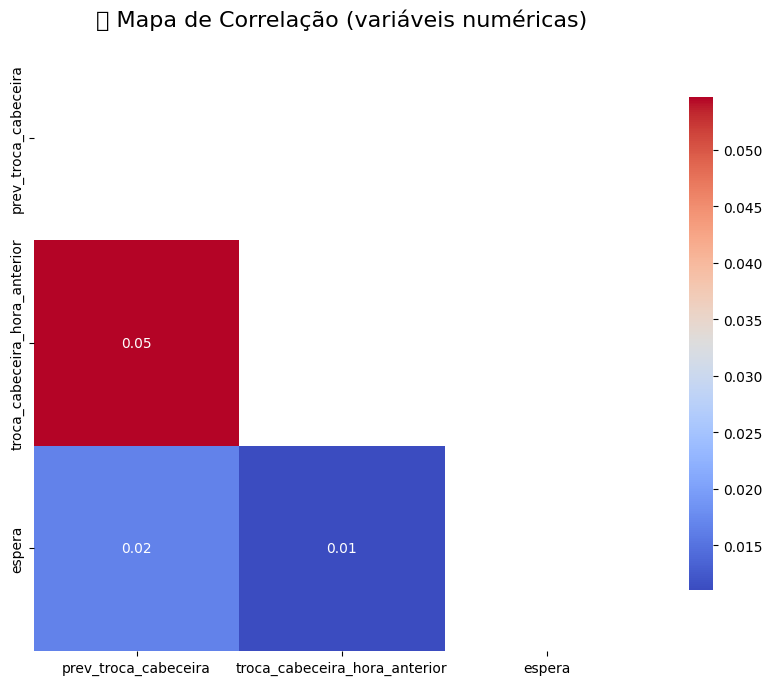

🔗 Correlação com 'espera':


prev_troca_cabeceira             0.016673
troca_cabeceira_hora_anterior    0.011102
Name: espera, dtype: float64

In [35]:
# Correlação numérica
plt.figure(figsize=(10, 8))
corr = df_public[num_cols].corr()

# Destaque para 'espera'
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', square=True,
            mask=np.triu(corr), cbar_kws={"shrink": .8})
plt.title("📈 Mapa de Correlação (variáveis numéricas)", fontsize=16)
plt.show()

# Correlação direta com 'espera'
espera_corr = corr['espera'].drop('espera').sort_values(key=abs, ascending=False)
print("🔗 Correlação com 'espera':")
display(espera_corr)


## 🧹 Etapa de Tratamento e Engenharia de Features

Nesta etapa, iremos tratar o conjunto de dados e realizar a criação de novas variáveis (features) que possam enriquecer a capacidade preditiva do modelo.

### 📌 Etapas previstas:

#### 1. **Filtragem e limpeza inicial**
- Separar os dados com e sem a variável alvo `espera`.
- Remover colunas irrelevantes ou não tratáveis no escopo atual:
  - `url_img_satelite`: sem uso direto sem modelo de visão computacional.
  - `metaf` e `metar`: só serão mantidos se processados via parsing.

#### 2. **Criação de colunas a partir de `hora_ref`**
- Extrair informações temporais úteis como:
  - Hora (`hora`)
  - Dia do mês (`dia`)
  - Dia da semana (`dia_semana`)
  - Parte do dia (manhã/tarde/noite/madrugada)
- Essas variáveis ajudam a capturar padrões operacionais e meteorológicos recorrentes.

#### 3. **Parsing meteorológico (`metar`, `metaf`)**
- Aplicar biblioteca `python-metar` para extrair variáveis numéricas como:
  - Velocidade e direção do vento
  - Pressão atmosférica
  - Temperatura e ponto de orvalho
  - Nível de nebulosidade
- Esses fatores são relevantes para operações de pouso/decolagem e podem influenciar a ocorrência de esperas.

#### 4. **Criação de defasagens (lags)**
- Gerar **lags temporais** de 1, 2 e 3 horas para colunas críticas, por aeroporto:
  - `prev_troca_cabeceira`
  - `troca_cabeceira_hora_anterior`
- O objetivo é capturar **tendências operacionais ou sequências** que antecedem esperas.

#### 5. **Codificação de variáveis categóricas**
- Aplicar codificação adequada:
  - `LabelEncoder` ou `One-Hot` para `origem`, `destino`, etc.

#### 6. **Tratamento de valores nulos**
- Decidir como tratar colunas parciais (ex: preencher com medianas, categorizar como "desconhecido", etc).

---

> Ao final dessa etapa, teremos um dataset limpo, enriquecido com novas variáveis e pronto para treinamento do modelo preditivo.


In [36]:
def extrair_temporais(df, col='hora_ref'):
    """
    Extrai múltiplas features de data e hora a partir da coluna 'hora_ref'.

    Parâmetros:
    -----------
    df : pd.DataFrame
        DataFrame contendo a coluna de data/hora.
    col : str
        Nome da coluna que contém os timestamps.

    Retorna:
    --------
    df : pd.DataFrame
        DataFrame original com novas colunas temporais adicionadas.
    """
    # Conversão segura para datetime
    df[col] = pd.to_datetime(df[col], errors='coerce')

    # Extrações básicas
    df['hora'] = df[col].dt.hour
    df['dia'] = df[col].dt.day
    df['mes'] = df[col].dt.month
    df['dia_semana'] = df[col].dt.weekday  # 0 = segunda, 6 = domingo
    df['fim_de_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

    # Faixas de horário (categorias)
    def faixa_horaria(hora):
        if 0 <= hora < 6:
            return 'madrugada'
        elif 6 <= hora < 12:
            return 'manha'
        elif 12 <= hora < 18:
            return 'tarde'
        else:
            return 'noite'
    
    df['periodo_dia'] = df['hora'].apply(faixa_horaria)

    return df

In [37]:
df_public = extrair_temporais(df_public)

df_public[['hora_ref', 'hora', 'dia_semana', 'periodo_dia']].head()

,hora_ref,hora,dia_semana,periodo_dia
0,2022-06-01 01:00:00+00:00,1,2,madrugada
1,2022-06-01 01:00:00+00:00,1,2,madrugada
2,2022-06-01 01:00:00+00:00,1,2,madrugada
3,2022-06-01 01:00:00+00:00,1,2,madrugada
4,2022-06-01 01:00:00+00:00,1,2,madrugada


In [38]:
import pandas as pd
import numpy as np
import re

In [39]:
def limpar_e_decodificar_public(df):
    """
    Limpa o df_public e decodifica informações relevantes dos campos METAR e METAF.
    """
    df = df.copy()

    # 1. Remover colunas totalmente nulas
    df.dropna(axis=1, how='all', inplace=True)

    # 2. Substituir NaNs em metar/metaf
    df['metar'] = df['metar'].fillna('None')
    df['metaf'] = df['metaf'].fillna('None')

    # 3. Limpar espaços e caracteres inválidos
    df['metar'] = df['metar'].str.strip().str.replace('\n', ' ').str.replace('////', '')
    df['metaf'] = df['metaf'].str.strip().str.replace('\n', ' ').str.replace('////', '')

    # 4. Criar funções auxiliares
    def extrair_visibilidade(mensagem):
        match = re.search(r'\b(\d{4})\b', mensagem)
        return int(match.group(1)) if match else np.nan

    def extrair_vento(mensagem):
        match = re.search(r'(\d{3})(\d{2})KT', mensagem)
        if match:
            direcao, velocidade = match.groups()
            return int(direcao), int(velocidade)
        return np.nan, np.nan

    def extrair_nuvens(mensagem):
        nuvens = re.findall(r'(FEW|SCT|BKN|OVC)(\d{3})', mensagem)
        return len(nuvens), [int(alt)*100 for _, alt in nuvens] if nuvens else (0, [])

    def decodificar(mensagem):
        visib = extrair_visibilidade(mensagem)
        direcao, vel = extrair_vento(mensagem)
        n_nuvens, alturas = extrair_nuvens(mensagem)
        return pd.Series([visib, direcao, vel, n_nuvens, alturas])

    # 5. Aplicar para metar e metaf
    df[['visib_metar', 'dir_vento_metar', 'vel_vento_metar', 'qtd_nuvens_metar', 'alturas_nuvens_metar']] = df['metar'].apply(decodificar)
    df[['visib_metaf', 'dir_vento_metaf', 'vel_vento_metaf', 'qtd_nuvens_metaf', 'alturas_nuvens_metaf']] = df['metaf'].apply(decodificar)

    return df

In [40]:
df_public_limpo = limpar_e_decodificar_public(df_public)
df_public_limpo[['metar', 'visib_metar', 'dir_vento_metar', 'qtd_nuvens_metar']].head()


,metar,visib_metar,dir_vento_metar,qtd_nuvens_metar
0,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,9999.0,170.0,1
1,METAR SBFL 010000Z 17009KT 140V200 9999 BKN030...,9999.0,170.0,1
2,METAR SBCF 010000Z 12006KT CAVOK 21/14 Q1018=,NaN,120.0,0
3,METAR SBCT 010000Z 10006KT 7000 -RA BKN004 OVC...,7000.0,100.0,2
4,METAR SBSV 010000Z 11008KT 9999 FEW023 27/21 Q...,9999.0,110.0,1


In [42]:
df_public_limpo.columns

Index(['flightid', 'hora_ref', 'origem', 'destino', 'url_img_satelite',
       'metaf', 'metar', 'prev_troca_cabeceira',
       'troca_cabeceira_hora_anterior', 'espera', 'hora', 'dia', 'mes',
       'dia_semana', 'fim_de_semana', 'periodo_dia', 'visib_metar',
       'dir_vento_metar', 'vel_vento_metar', 'qtd_nuvens_metar',
       'alturas_nuvens_metar', 'visib_metaf', 'dir_vento_metaf',
       'vel_vento_metaf', 'qtd_nuvens_metaf', 'alturas_nuvens_metaf'],
      dtype='object')

In [74]:
def tratar_alturas_nuvens(col):
    def extrair_media(x):
        if isinstance(x, list):
            return np.mean([float(i) for i in x if i is not None])
        elif isinstance(x, str):
            try:
                # Tenta converter string tipo '[2000, 3000]' ou '3000'
                if x.startswith("[") and x.endswith("]"):
                    return np.mean([float(i) for i in x.strip("[]").split(",")])
                else:
                    return float(x)
            except:
                return np.nan
        elif pd.isnull(x):
            return np.nan
        else:
            try:
                return float(x)
            except:
                return np.nan
    return col.apply(extrair_media)


In [75]:
df_public_limpo['alturas_nuvens_metar'] = tratar_alturas_nuvens(df_public_limpo['alturas_nuvens_metar'])


In [76]:
def adicionar_lags_e_medias_moveis(df, colunas, n_lags=[1,2,3], janelas=[3]):
    df = df.copy()
    
    for coluna in colunas:
        try:
            # Força conversão para float numérica (ignora erros)
            df[coluna] = pd.to_numeric(df[coluna], errors='coerce')

            # Preenche NaNs com ffill + bfill
            df[coluna] = df[coluna].fillna(method='ffill').fillna(method='bfill')
            
            # Criação de lags
            for lag in n_lags:
                df[f'{coluna}_lag_{lag}'] = df[coluna].shift(lag)

            # Média móvel
            for janela in janelas:
                df[f'{coluna}_mm_{janela}h'] = df[coluna].rolling(window=janela, min_periods=1).mean()
        
        except Exception as e:
            print(f"⚠️ Erro na coluna {coluna}: {e}")
    
    return df


In [77]:
def preencher_nulos_para_lags(df, colunas, grupo='origem'):
    df = df.copy()
    for col in colunas:
        df[col] = (
            df.groupby(grupo)[col]
              .transform(lambda x: pd.to_numeric(x, errors='coerce').fillna(method='ffill').fillna(method='bfill'))
        )
    return df


In [78]:
df_public_limpo['hora_ref'] = pd.to_datetime(df_public_limpo['hora_ref'])


In [79]:
colunas_para_lags = [
    'vel_vento_metar', 'qtd_nuvens_metar', 'visib_metar',
    'dir_vento_metar', 'alturas_nuvens_metar'
]

df_public_com_lags = adicionar_lags_e_medias_moveis(df_public_limpo, colunas_para_lags)



In [80]:
df_public_com_lags[[col for col in df_public_com_lags.columns if '_lag_' in col or '_mm_' in col]].dtypes


vel_vento_metar_lag_1         float64
vel_vento_metar_lag_2         float64
vel_vento_metar_lag_3         float64
vel_vento_metar_mm_3h         float64
qtd_nuvens_metar_lag_1        float64
qtd_nuvens_metar_lag_2        float64
qtd_nuvens_metar_lag_3        float64
qtd_nuvens_metar_mm_3h        float64
visib_metar_lag_1             float64
visib_metar_lag_2             float64
visib_metar_lag_3             float64
visib_metar_mm_3h             float64
dir_vento_metar_lag_1         float64
dir_vento_metar_lag_2         float64
dir_vento_metar_lag_3         float64
dir_vento_metar_mm_3h         float64
alturas_nuvens_metar_lag_1    float64
alturas_nuvens_metar_lag_2    float64
alturas_nuvens_metar_lag_3    float64
alturas_nuvens_metar_mm_3h    float64
dtype: object

In [81]:
df_public_limpo.isnull().sum()

flightid                              0
hora_ref                              0
origem                                0
destino                               0
url_img_satelite                   3733
metaf                                 0
metar                                 0
prev_troca_cabeceira                  0
troca_cabeceira_hora_anterior         0
espera                            90720
hora                                  0
dia                                   0
mes                                   0
dia_semana                            0
fim_de_semana                         0
periodo_dia                           0
visib_metar                       82867
dir_vento_metar                   20199
vel_vento_metar                   20199
qtd_nuvens_metar                      0
alturas_nuvens_metar              89858
visib_metaf                      207519
dir_vento_metaf                  146662
vel_vento_metaf                  146662
qtd_nuvens_metaf                      0


In [89]:
def preencher_nulos_com_media(df):
    df_preenchido = df.copy()
    colunas_numericas = df_preenchido.select_dtypes(include='number').columns
    for col in colunas_numericas:
        media = df_preenchido[col].mean()
        df_preenchido[col] = df_preenchido[col].fillna(media)
    return df_preenchido


In [90]:
df_public_sem_nulos = preencher_nulos_com_media(df_public_limpo)


In [92]:
df_public_sem_nulos.isnull().sum()


flightid                            0
hora_ref                            0
origem                              0
destino                             0
url_img_satelite                 3733
metaf                               0
metar                               0
prev_troca_cabeceira                0
troca_cabeceira_hora_anterior       0
espera                              0
hora                                0
dia                                 0
mes                                 0
dia_semana                          0
fim_de_semana                       0
periodo_dia                         0
visib_metar                         0
dir_vento_metar                     0
vel_vento_metar                     0
qtd_nuvens_metar                    0
alturas_nuvens_metar                0
visib_metaf                         0
dir_vento_metaf                     0
vel_vento_metaf                     0
qtd_nuvens_metaf                    0
alturas_nuvens_metaf                0
dtype: int64

In [95]:
# Fazendo o merge com base no flightid
df_merged = pd.merge(
    df_public_sem_nulos,
    df_pca.drop(columns=['hora_ref', 'origem', 'destino', 'url_img_satelite',
                         'metaf', 'metar', 'prev_troca_cabeciera',
                         'troca_cabeciera_hora_anterior', 'espera'], errors='ignore'),
    on='flightid',
    how='left'
)


In [96]:
df_merged.info()
df_merged.isnull().sum().sort_values(ascending=False).head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302399 entries, 0 to 302398
Columns: 253 entries, flightid to pca_224
dtypes: datetime64[ns, UTC](1), float64(235), int32(5), int64(4), object(8)
memory usage: 577.9+ MB


pca_98     293934
pca_146    293934
pca_133    293934
pca_134    293934
pca_135    293934
pca_136    293934
pca_137    293934
pca_138    293934
pca_139    293934
pca_140    293934
dtype: int64

In [97]:
df_merged.isnull().sum()

flightid                 0
hora_ref                 0
origem                   0
destino                  0
url_img_satelite      3733
                     ...  
pca_220             293934
pca_221             293934
pca_222             293934
pca_223             293934
pca_224             293934
Length: 253, dtype: int64

In [98]:
df_pca.isnull().sum()

flightid            0
hora_ref            0
origem              0
destino             0
url_img_satelite    1
                   ..
pca_220             0
pca_221             0
pca_222             0
pca_223             0
pca_224             0
Length: 235, dtype: int64

In [99]:
# Verificar flightids que não deram match
ids_public = set(df_public_sem_nulos['flightid'])
ids_pca = set(df_pca['flightid'])

ids_faltantes = ids_public - ids_pca
print(f'FlightIDs sem correspondência no df_pca: {len(ids_faltantes)}')


FlightIDs sem correspondência no df_pca: 293934


In [100]:
df_merged_valido = df_public_sem_nulos.merge(df_pca, on='flightid', how='inner')
print(df_merged_valido.shape)


(8465, 260)


In [103]:
df_merged_valido.info()
df_merged_valido.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8465 entries, 0 to 8464
Columns: 260 entries, flightid to pca_224
dtypes: datetime64[ns, UTC](1), float64(234), int32(5), int64(6), object(14)
memory usage: 16.6+ MB


flightid              0
hora_ref_x            0
origem_x              0
destino_x             0
url_img_satelite_x    1
                     ..
pca_220               0
pca_221               0
pca_222               0
pca_223               0
pca_224               0
Length: 260, dtype: int64

In [109]:
df_merged_valido = df_merged_valido.dropna(subset=['espera_y'])


In [111]:
from sklearn.model_selection import train_test_split

# Separar features e target
X = df_merged_valido.drop(columns=['espera_y'])
y = df_merged_valido['espera_y']

# Separar treino e validação
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Remover NaNs do treino
train_data = pd.concat([X_train, y_train], axis=1).dropna()
X_train = train_data.drop(columns=['espera_y'])
y_train = train_data['espera_y']

# Garantir que validação também não tem NaN
X_valid = X_valid.dropna()
y_valid = y_valid.loc[X_valid.index]

In [117]:
# 1. Separar X e y
y = df_merged_valido['espera_y']
X = df_merged_valido.drop(columns=['espera_y'])

# 2. Remover colunas não numéricas
X = X.select_dtypes(include=['int64', 'float64'])

# 3. Agora pode seguir com split e pipeline
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 4. Pipeline com SMOTE e modelagem
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)


In [118]:
pipeline.fit(X_train, y_train)

# Previsão e avaliação
from sklearn.metrics import classification_report
y_pred = pipeline.predict(X_valid)
print(classification_report(y_valid, y_pred))


              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1192
         1.0       1.00      0.41      0.58        17

    accuracy                           0.99      1209
   macro avg       1.00      0.71      0.79      1209
weighted avg       0.99      0.99      0.99      1209



In [154]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import pandas as pd
import numpy as np

def pipeline_kaggle_val_real(df_public, df_pca, df_sample, n_splits=5):
    df_merged = df_public.merge(df_pca, on='flightid', how='inner')
    df_merged = df_merged[~df_merged['espera_y'].isna()]
    
    X = df_merged.drop(columns=['espera_y', 'flightid'])
    y = df_merged['espera_y']

    if 'hora_ref' in X.columns:
        X['hora_ref'] = X['hora_ref'].astype('int64')
    
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    X[cat_cols] = X[cat_cols].fillna('desconhecido').astype(str)
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[cat_cols] = encoder.fit_transform(X[cat_cols])
    X = X.fillna(-999)

    numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns

    print("\n📊 Validação cruzada com SMOTE:")
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_idx][numeric_cols], X.iloc[val_idx][numeric_cols]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

        model = CatBoostClassifier(random_state=42, verbose=0)
        model.fit(X_train_res, y_train_res)

        y_pred = model.predict(X_val)
        report = classification_report(y_val, y_pred, output_dict=True, zero_division=0)
        f1 = report['weighted avg']['f1-score']
        scores.append(f1)

        print(f"\n🔁 Fold {fold + 1}")
        print(classification_report(y_val, y_pred, zero_division=0))

    print(f"\n✅ F1-score médio (validação cruzada): {np.mean(scores):.4f}")

    # Submissão
    df_pred = df_sample.merge(df_pca, on='flightid', how='left').merge(df_public, on='flightid', how='left')
    X_sub = df_pred.drop(columns=['flightid'], errors='ignore')

    if 'hora_ref' in X_sub.columns:
        X_sub['hora_ref'] = X_sub['hora_ref'].astype('int64')
    X_sub[cat_cols] = X_sub[cat_cols].fillna('desconhecido').astype(str)
    X_sub[cat_cols] = encoder.transform(X_sub[cat_cols])
    X_sub = X_sub.fillna(-999)
    X_sub = X_sub[numeric_cols]

    final_model = CatBoostClassifier(random_state=42, verbose=0)
    final_model.fit(X[numeric_cols], y)
    preds = final_model.predict(X_sub)

    df_sub = pd.DataFrame({
        'flightid': df_sample['flightid'],
        'espera': preds
    })

    return final_model, df_sub


In [155]:
modelo, df_sub = pipeline_kaggle_val_real(df_public, df_pca, df_sample)



📊 Validação cruzada com SMOTE:

🔁 Fold 1
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1192
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00      1209
   macro avg       1.00      1.00      1.00      1209
weighted avg       1.00      1.00      1.00      1209


🔁 Fold 2
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1192
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00      1209
   macro avg       1.00      1.00      1.00      1209
weighted avg       1.00      1.00      1.00      1209


🔁 Fold 3
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1192
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00      1209
   macro avg       1.00      1.00      1.00      1209
weighted avg

KeyboardInterrupt: 

In [158]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
from catboost import CatBoostClassifier
import numpy as np
import pandas as pd

def pipeline_kaggle_crossval(df_public, df_pca, df_sample, n_splits=5):
    # Merge datasets
    df_merged = df_public.merge(df_pca, on='flightid', how='inner')
    df_merged = df_merged[~df_merged['espera_y'].isna()]
    
    X = df_merged.drop(columns=['flightid', 'espera_y'])
    y = df_merged['espera_y']

    # Conversão de datas
    if 'hora_ref' in X.columns:
        X['hora_ref'] = X['hora_ref'].astype('int64')
    
    # Encoding
    cat_cols = X.select_dtypes(include='object').columns.tolist()
    X[cat_cols] = X[cat_cols].fillna('desconhecido').astype(str)
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[cat_cols] = encoder.fit_transform(X[cat_cols])
    X = X.fillna(-999)

    numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # Validação cruzada real
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    f1_scores = []

    print("\n📊 Avaliação por validação cruzada estratificada:")
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, y_train = X.iloc[train_idx][numeric_cols], y.iloc[train_idx]
        X_val, y_val = X.iloc[val_idx][numeric_cols], y.iloc[val_idx]

        X_train_res, y_train_res = SMOTE(random_state=42).fit_resample(X_train, y_train)

        model = CatBoostClassifier(random_state=42, verbose=0)
        model.fit(X_train_res, y_train_res)

        y_pred = model.predict(X_val)
        report = classification_report(y_val, y_pred, zero_division=0, output_dict=True)
        print(f"\nFold {fold+1}:\n", classification_report(y_val, y_pred, zero_division=0))
        f1_scores.append(report['weighted avg']['f1-score'])

    print(f"\n✅ F1 médio (validação cruzada): {np.mean(f1_scores):.4f}")

    # Treinamento final com todos os dados
    final_model = CatBoostClassifier(random_state=42, verbose=0)
    final_model.fit(X[numeric_cols], y)

    # Preparação para submissão
    df_pred = df_sample.merge(df_pca, on='flightid', how='left').merge(df_public, on='flightid', how='left')
    X_sub = df_pred.drop(columns=['flightid'], errors='ignore')

    if 'hora_ref' in X_sub.columns:
        X_sub['hora_ref'] = X_sub['hora_ref'].astype('int64')
    X_sub[cat_cols] = X_sub[cat_cols].fillna('desconhecido').astype(str)
    X_sub[cat_cols] = encoder.transform(X_sub[cat_cols])
    X_sub = X_sub.fillna(-999)
    X_sub = X_sub[numeric_cols]

    preds = final_model.predict(X_sub)

    df_sub = pd.DataFrame({
        'flightid': df_sample['flightid'],
        'espera': preds
    })

    return final_model, df_sub


In [159]:
modelo, df_sub = pipeline_kaggle_crossval(df_public, df_pca, df_sample)



📊 Avaliação por validação cruzada estratificada:

Fold 1:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1192
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00      1209
   macro avg       1.00      1.00      1.00      1209
weighted avg       1.00      1.00      1.00      1209


Fold 2:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1192
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00      1209
   macro avg       1.00      1.00      1.00      1209
weighted avg       1.00      1.00      1.00      1209


Fold 3:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1192
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00      1209
   macro avg       1.00      1.00      1.00     

KeyboardInterrupt: 

In [175]:
def pipeline_kaggle_refatorado(df_public, df_pca, df_sample):
    import pandas as pd
    import numpy as np
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import OrdinalEncoder
    from sklearn.metrics import classification_report
    from imblearn.over_sampling import ADASYN
    from xgboost import XGBClassifier

    # 1. Merge público + PCA
    df_merged = df_public.merge(df_pca, on='flightid', how='inner')
    df_merged = df_merged[~df_merged['espera_y'].isna()]

    # 2. Engenharia de features temporais
    if 'hora_ref' in df_merged.columns:
        df_merged['hora_ref'] = pd.to_datetime(df_merged['hora_ref'], errors='coerce')
        df_merged['hora_ref_hour'] = df_merged['hora_ref'].dt.hour
        df_merged['hora_ref_periodo'] = pd.cut(df_merged['hora_ref_hour'],
                                               bins=[-1, 5, 12, 18, 24],
                                               labels=['madrugada', 'manha', 'tarde', 'noite'])
        df_merged['is_weekend'] = df_merged['hora_ref'].dt.dayofweek >= 5

    # 3. Prepara dados
    drop_cols = ['espera_y', 'flightid']
    if 'hora_ref' in df_merged.columns:
        drop_cols.append('hora_ref')

    X = df_merged.drop(columns=drop_cols, errors='ignore')
    y = df_merged['espera_y']

    # 4. Codificação de categorias
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
    X[cat_cols] = X[cat_cols].fillna('desconhecido').astype(str)
    encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X[cat_cols] = encoder.fit_transform(X[cat_cols])
    X = X.fillna(-999)

    # 5. Remove colunas datetime
    # 5. Remove qualquer coluna datetime de forma segura
    from pandas.api.types import is_datetime64_any_dtype

    # Remove qualquer coluna datetime (mesmo com timezone como UTC)
    for col in X.columns:
        if is_datetime64_any_dtype(X[col]):
            X = X.drop(columns=col)



    # 6. Split
    X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    # 7. Balanceamento com ADASYN
    ada = ADASYN(random_state=42)
    X_train_res, y_train_res = ada.fit_resample(X_train, y_train)

    # 8. Modelo com XGBoost
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    modelo = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                           scale_pos_weight=scale_pos_weight)
    modelo.fit(X_train_res, y_train_res)

    # 9. Avaliação
    y_val_pred = modelo.predict(X_val)
    print("\n📊 Relatório de classificação (validação):")
    print(classification_report(y_val, y_val_pred))

    # 10. Previsão para submissão
    df_pred = df_sample.merge(df_pca, on='flightid', how='left')
    df_pred = df_pred.merge(df_public, on='flightid', how='left')

    if 'hora_ref' in df_pred.columns:
        df_pred['hora_ref'] = pd.to_datetime(df_pred['hora_ref'], errors='coerce')
        df_pred['hora_ref_hour'] = df_pred['hora_ref'].dt.hour
        df_pred['hora_ref_periodo'] = pd.cut(df_pred['hora_ref_hour'],
                                             bins=[-1, 5, 12, 18, 24],
                                             labels=['madrugada', 'manha', 'tarde', 'noite'])
        df_pred['is_weekend'] = df_pred['hora_ref'].dt.dayofweek >= 5

    X_sub = df_pred.drop(columns=['flightid', 'hora_ref'], errors='ignore')

    # Garante que todas as colunas categóricas estejam tratadas
    for col in cat_cols:
        if col not in X_sub.columns:
            X_sub[col] = 'desconhecido'
        X_sub[col] = X_sub[col].astype(str).fillna('desconhecido')
    X_sub[cat_cols] = encoder.transform(X_sub[cat_cols])

    # Fill geral + drop de datetime
    X_sub = X_sub.fillna(-999)
    X_sub = X_sub.drop(columns=X_sub.select_dtypes(include=['datetime64[ns]', 'datetime']).columns, errors='ignore')

    # Predição
    preds = modelo.predict(X_sub)

    df_sub = pd.DataFrame({
        'flightid': df_sample['flightid'],
        'espera': preds.astype(int)
    })

    return modelo, df_sub


In [176]:
modelo, df_sub = pipeline_kaggle_refatorado(df_public, df_pca, df_sample)



📊 Relatório de classificação (validação):
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      1192
         1.0       1.00      1.00      1.00        17

    accuracy                           1.00      1209
   macro avg       1.00      1.00      1.00      1209
weighted avg       1.00      1.00      1.00      1209



ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, The experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:hora_ref_x: object